# How to choose between COBA and CUBA synapses

**Task.** Decide whether a projection should be **conductance-based** (COBA) or
**current-based** (CUBA), and switch between them with a one-line change.

**Audience.** Simulation. Assumes {doc}`../tutorials/02-synapse-and-projection`.

The `out=` argument of a projection controls how the synaptic variable enters
the postsynaptic neuron:

- **`COBA(E=...)`** — *conductance-based*. The synaptic current is
  `g · (E − V)`: it depends on the postsynaptic voltage and saturates near the
  reversal potential `E`. This is the biophysically faithful choice.
- **`CUBA(scale=...)`** — *current-based*. The synaptic variable is injected as a
  current independent of `V`. Simpler and often used in analysis and in
  brain-inspired models.

Everything else about the projection stays the same.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## One network, swappable output

We parametrize the E/I network by the output describer so we can build a COBA
version and a CUBA version from the same class. (This is the Vogels–Abbott
balanced network; the COBA form is Tutorial 3.)

In [2]:
class EINet(brainstate.nn.Module):
    def __init__(self, exc_out, inh_out, exc_w, inh_w):
        super().__init__()
        self.n_exc, self.n_inh = 3200, 800
        self.num = self.n_exc + self.n_inh
        self.N = brainpy.state.LIFRef(
            self.num, V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
            tau=20. * u.ms, tau_ref=5. * u.ms,
            V_initializer=braintools.init.Normal(-55., 2., unit=u.mV))
        self.E = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_exc, self.num, conn_num=0.02, conn_weight=exc_w),
            syn=brainpy.state.Expon.desc(self.num, tau=5. * u.ms),
            out=exc_out, post=self.N)
        self.I = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_inh, self.num, conn_num=0.02, conn_weight=inh_w),
            syn=brainpy.state.Expon.desc(self.num, tau=10. * u.ms),
            out=inh_out, post=self.N)

    def update(self, t, inp):
        with brainstate.environ.context(t=t):
            spk = self.N.get_spike() != 0.
            self.E(spk[:self.n_exc]); self.I(spk[self.n_exc:]); self.N(inp)
            return self.N.get_spike()


def simulate(net, t_stop=500. * u.ms):
    brainstate.nn.init_all_states(net)
    with brainstate.environ.context(dt=0.1 * u.ms):
        times = u.math.arange(0. * u.ms, t_stop, brainstate.environ.get_dt())
        spikes = brainstate.transform.for_loop(
            lambda t: net.update(t, 20. * u.mA), times)
    return times, spikes

## Conductance-based (COBA)

Excitation reverses at 0 mV, inhibition at −80 mV; weights are conductances in
millisiemens.

In [3]:
with brainstate.environ.context(dt=0.1 * u.ms):
    coba = EINet(
        exc_out=brainpy.state.COBA.desc(E=0. * u.mV),
        inh_out=brainpy.state.COBA.desc(E=-80. * u.mV),
        exc_w=0.6 * u.mS, inh_w=6.7 * u.mS)
times_coba, spk_coba = simulate(coba)

## Current-based (CUBA)

Same wiring, but `out=CUBA(scale=...)` injects a current directly; inhibitory
weights are simply negative. No reversal potential is involved.

In [4]:
with brainstate.environ.context(dt=0.1 * u.ms):
    cuba = EINet(
        exc_out=brainpy.state.CUBA.desc(scale=u.volt),
        inh_out=brainpy.state.CUBA.desc(scale=u.volt),
        exc_w=1.62 * u.mS, inh_w=-9.0 * u.mS)
times_cuba, spk_cuba = simulate(cuba)

## Compare the rasters

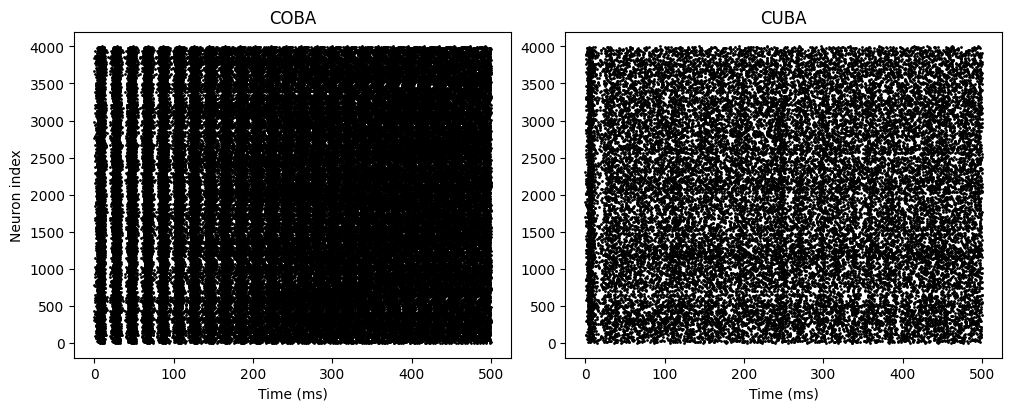

In [5]:
fig, gs = braintools.visualize.get_figure(1, 2, 4.0, 5.0)
for k, (title, times, spk) in enumerate(
        [('COBA', times_coba, spk_coba), ('CUBA', times_cuba, spk_cuba)]):
    ax = fig.add_subplot(gs[0, k])
    ti, ni = u.math.where(spk)
    ax.scatter(times[ti].to_decimal(u.ms), ni, s=1, color='k')
    ax.set_title(title); ax.set_xlabel('Time (ms)')
    if k == 0:
        ax.set_ylabel('Neuron index')
plt.show()

## See also

- {doc}`/concepts/alignpre-alignpost` — why the synaptic state is exponential
  and aligned to the postsynaptic side.
- {doc}`/apis/brainpy-synouts` — `COBA`, `CUBA`, and `MgBlock` reference.
- {doc}`sim-short-term-plasticity` — make synapses dynamic.